Pentru prima parte a proiectului, am ales să generez sintetic un set de date destinat unei probleme de clasificare. Mai exact, modelul va trebui să prezică din ce categorie de vârstă face parte o persoană, analizând date despre stilul ei de viață și situația financiară.

Ca să respect cerințele, am avut grijă ca datele să nu fie pur aleatoare, ci să aibă sens contextual – de exemplu, venitul și ocupația se schimbă în mod realist în funcție de vârstă. În blocul de cod de mai jos îmi pregătesc mediul de lucru: import bibliotecile necesare și definesc categoriile de vârstă

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(17)
random.seed(17)
date = []
categorii = ["18-25", "26-39", "40-59", "60+"]

Am scris o buclă care rulează de 800 de ori pentru a mă asigura că obțin suficiente înregistrări pentru subseturile de antrenare și testare.

Pentru fiecare persoană simulată, codul alege mai întâi grupa de vârstă, iar apoi aplică logica pe care am gândit-o: folosesc probabilități pentru a genera un venit, un nivel de stres și economii realiste, specifice acelei etape din viață. De exemplu, persoanele la mijlocul carierei câștigă mai bine și au economii mai mari, dar sunt adesea mult mai stresate.

La finalul fiecărui pas, m-am asigurat că datele nu devin absurde – tăind din start eventualele venituri negative sau un nivel de stres mai mare de 10 – și am adăugat rândul calculat în lista mea de date.

In [13]:
n = 800
for i in range(n):
    varsta = random.choice(categorii)
    if varsta == "18-25":
      ocupatie = random.choices(["Student", "Programator Junior", "Casier"], weights=[0.7, 0.2, 0.1])[0]
      venit = round(np.random.normal(2000, 700), 2)
      stare_civila = "Necasatorit"
      economii = round(np.random.normal(1000, 200), 2)
      ore_ecran_zilnic = int(np.random.normal(7, 3))
      nivel_stres = round(np.random.normal(5, 1), 2)
      timp_liber = int(np.random.normal(30, 10))
    elif varsta == "26-39":
      ocupatie = random.choices(["Programator", "Avocat", "Antreprenor", "Arhitect"], weights=[0.4, 0.3, 0.2, 0.1])[0]
      venit = round(np.random.normal(7000, 3000), 2)
      stare_civila = random.choice(["Necasatorit", "Casatorit"])
      economii = round(np.random.normal(50000, 10000), 2)
      ore_ecran_zilnic = int(np.random.normal(8, 3))
      nivel_stres = round(np.random.normal(8, 4), 2)
      timp_liber = int(np.random.normal(17, 5))
    elif varsta == "40-59":
      ocupatie = random.choices(["Manager", "Medic", "Programator Senior", "Familie"], weights=[0.3, 0.3, 0.3, 0.1])[0]
      venit = round(np.random.normal(10000, 6000), 2)
      stare_civila = random.choice(["Casatorit", "Divortat"])
      economii = round(np.random.normal(100000, 50000), 2)
      ore_ecran_zilnic = int(np.random.normal(6, 2))
      nivel_stres = round(np.random.normal(8, 2), 2)
      timp_liber = int(np.random.normal(20, 10))
    else:
      ocupatie = "Pensionar"
      venit = round(np.random.normal(5000, 1200), 2)
      stare_civila = random.choice(["Casatorit", "Vaduv"])
      economii = round(np.random.normal(10000, 5000), 2)
      ore_ecran_zilnic = int(np.random.normal(3, 0))
      nivel_stres = round(np.random.normal(3, 1), 2)
      timp_liber = int(np.random.normal(40, 15))
    venit = max(0, venit)
    economii = max(0, economii)
    ore_ecran_zilnic = max(0, min(24, ore_ecran_zilnic))
    nivel_stres = max(1, min(10, nivel_stres))
    timp_liber = max(0, timp_liber)

    date.append([varsta, ocupatie, venit, stare_civila, economii, ore_ecran_zilnic, nivel_stres, timp_liber])

In acest ultim pas al generării, am transformat lista de date într-un format tabelar, folosind un DataFrame din biblioteca pandas, și am denumit sugestiv fiecare coloană.

Pentru a respecta cerințele proiectului legate de analiza exploratorie, a trebuit să introduc intenționat puține probleme în date. Astfel, am selectat aleatoriu aproximativ 5% dintre înregistrări și le-am șters valoarea pentru orele de ecran zilnic, simulând astfel valori lipsă. De asemenea, am creat trei valori extreme setând nivelul de stres la 12, o valoare imposibilă pe scara mea de la 1 la 10, pe care o voi detecta și trata ulterior în analiză.

La final, am împărțit setul de date în două subseturi distincte, prin extragere randomizată. Folosind o proporție de 30% pentru testare, mi-am garantat că obțin peste 500 de instanțe pentru antrenarea modelului și peste 200 de instanțe pentru testare. Cele două subseturi au fost apoi exportate și salvate pe disc sub formă de fișiere CSV separate, fiind acum perfect pregătite pentru etapa de analiză exploratorie și antrenare.  

In [14]:
nume_coloane = ["Categorie varsta", "Ocupatie", "Venit", "Stare civila", "Economii", "Ore ecran zilnic", "Nivel stres", "Timp liber"]
df = pd.DataFrame(date, columns=nume_coloane)
indici_nan = random.sample(range(n), int(n * 0.07))
df.loc[indici_nan, "Ore ecran zilnic"] = np.nan
indici_extremi = random.sample(range(n), 3)
df.loc[indici_extremi, "Nivel stres"] = 12
train_df, test_df = train_test_split(df, test_size=0.3, random_state=17)
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(f"Date de antrenare salvate: {train_df.shape[0]} rânduri")
print(f"Date de testare salvate: {test_df.shape[0]} rânduri")

Date de antrenare salvate: 560 rânduri
Date de testare salvate: 240 rânduri


In codul de mai jos voi încărca fișierul de antrenare pentru a vedea exact unde am goluri.

După ce detectez procentul de date lipsă de pe coloana referitoare la orele de ecran, le repar. Voi înlocuii spațiile goale cu mediana orelor de ecran din restul tabelului. Am preferat mediana în loc de media aritmetică clasică deoarece mediana nu este influențată și trasă în sus de valorile extreme.

In [15]:
sns.set_theme(style="darkgrid")
train_df = pd.read_csv("train.csv")
valori_lipsa = train_df.isnull().sum()
lipsa = (valori_lipsa / len(train_df)) * 100
df_lipsa = pd.DataFrame({"Valori lipsă": valori_lipsa, "Procent": lipsa})
print(df_lipsa[df_lipsa['Valori lipsă'] > 0])

media_ore = train_df['Ore ecran zilnic'].median()
train_df['Ore ecran zilnic'] = train_df['Ore ecran zilnic'].fillna(media_ore)

print(f"Verificare finală valori lipsă: {train_df['Ore ecran zilnic'].isnull().sum()}")


                  Valori lipsă   Procent
Ore ecran zilnic            40  7.142857
Verificare finală valori lipsă: 0


Următorul pas constă in generarea, mai întâi, a unui set de statistici descriptive. Funcția describe() este perfectă aici, deoarece îmi calculează instant mediile, valorile minime și maxime pentru datele numerice, dar îmi arată și care sunt cele mai frecvente categorii pentru datele de tip text.

Am ales să și desenez câteva grafice de bază. Voi folosi o histogramă pentru a vedea cum sunt distribuite veniturile în tabelul meu și două grafice cu bare pentru a număra rapid câte persoane fac parte din fiecare ocupație și stare civilă.

Statistici pentru variabilele numerice


,Venit,Economii,Ore ecran zilnic,Nivel stres,Timp liber
count,560.000000,560.000000,560.000000,560.000000,560.000000
mean,5999.304089,42613.040482,5.626786,5.699286,27.200000
std,4277.162044,49337.940193,2.740734,2.636211,14.249477
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2727.015000,1346.945000,3.000000,3.630000,16.000000
50%,5062.915000,18547.330000,5.000000,5.280000,25.000000
75%,8346.172500,60004.307500,7.000000,7.772500,35.250000
max,21319.830000,267257.870000,15.000000,12.000000,79.000000


Statistici pentru variabilele categorice


,Categorie varsta,Ocupatie,Stare civila
count,560,560,560
unique,4,12,4
top,18-25,Pensionar,Casatorit
freq,141,137,209


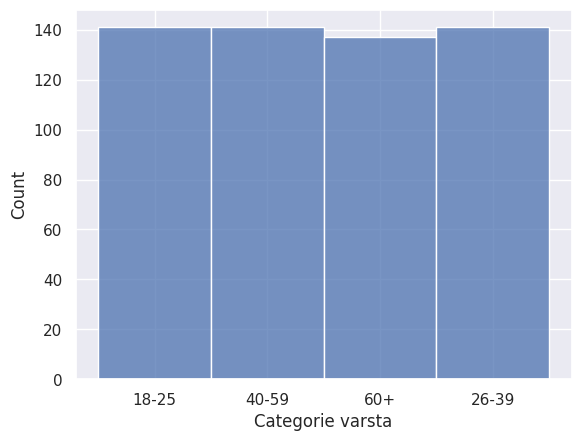

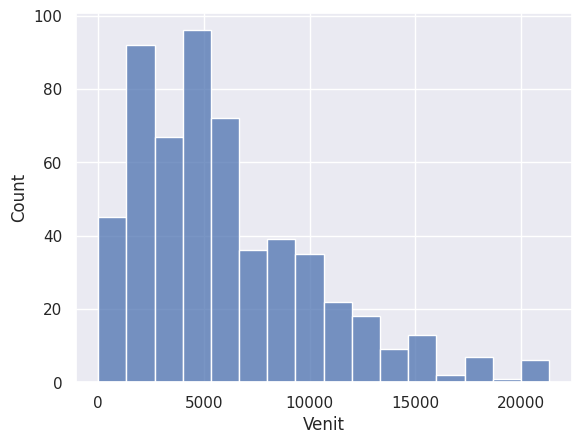

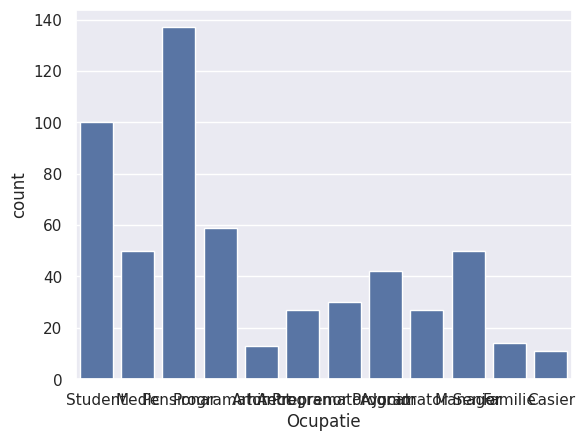

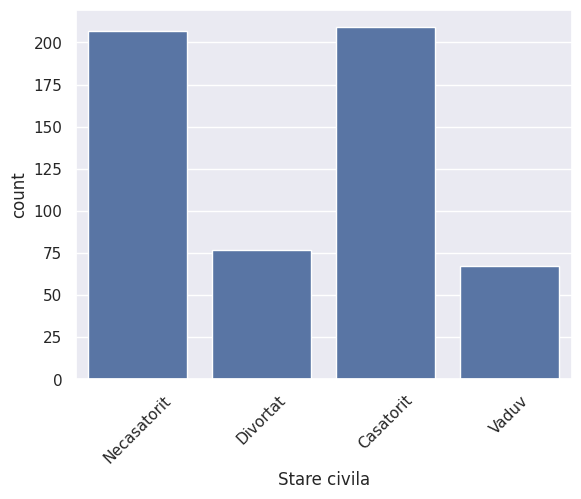

In [16]:
print("Statistici pentru variabilele numerice")
display(train_df.describe())
print("Statistici pentru variabilele categorice")
display(train_df.describe(include=['object']))
sns.histplot(data=train_df, x='Categorie varsta')
plt.show()
sns.histplot(data=train_df, x='Venit')
plt.show()
sns.countplot(data=train_df, x='Ocupatie')
plt.show()
sns.countplot(data=train_df, x='Stare civila')
plt.xticks(rotation=45)
plt.show()

În acest ultim pas al explorării datelor, verific două lucruri: dacă am valori extreme și cum interacționează variabilele între ele.

Primul grafic de mai jos este un Boxplot pe coloana de stres. L-am folosit pentru că este cel mai bun instrument ca să scoată în evidență valorile aberante. Așa cum o să se vadă imediat după ce rulez codul, graficul izolează perfect acel nivel de stres de 12 pe care l-am strecurat intenționat la începutul proiectului.

Al doilea grafic este un Heatmap. E un tabel care îmi arată matematic dacă se leagă vreo coloană de alta. De exemplu, e complet logic ca oamenii cu un venit mai mare să aibă și economii mai consistente, iar harta asta termică îmi confirmă. Așa demonstrez practic că am generat niște date care chiar au sens și seamănă cu realitatea.

Grafic nivel de stres


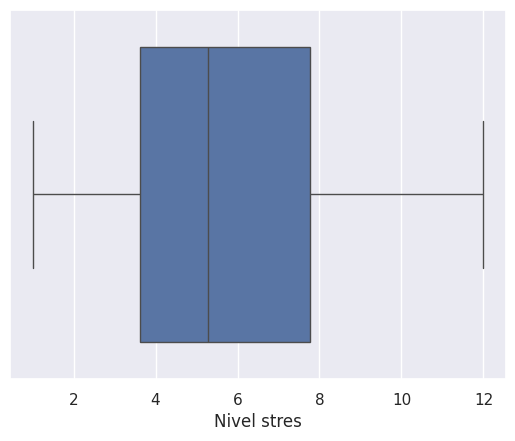

Grafic corelatii numerice


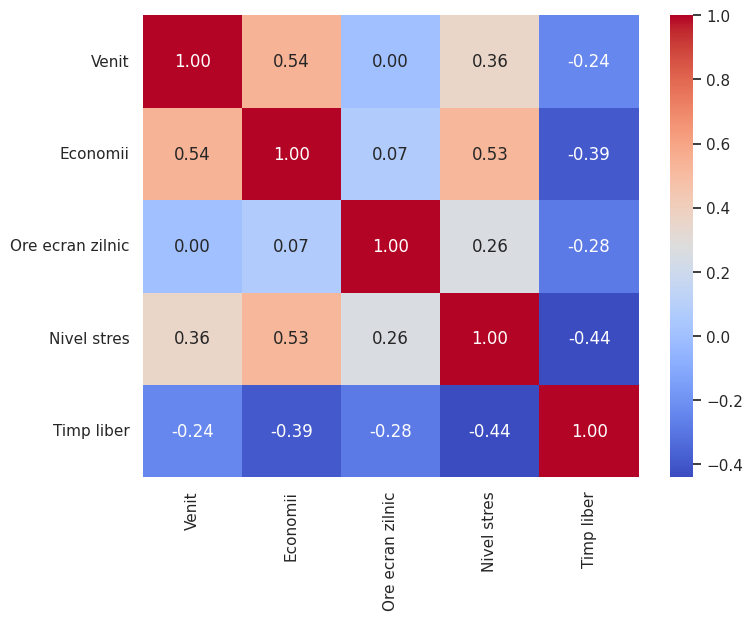


 Grafic relatia cu variabila tinta


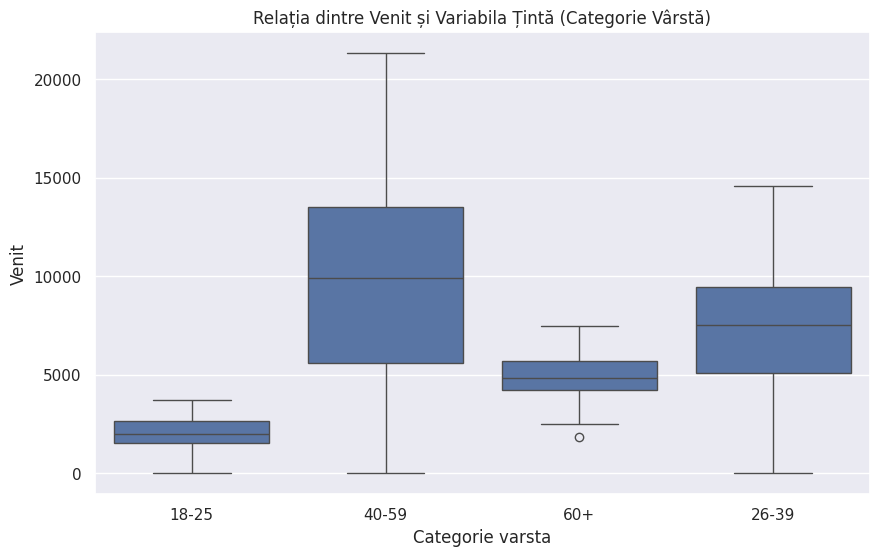

In [17]:
print("Grafic nivel de stres")
sns.boxplot(data=train_df, x='Nivel stres')
plt.show()
print("Grafic corelatii numerice")
train_df['Nivel stres'] = np.where(train_df['Nivel stres'] > 10, 10, train_df['Nivel stres'])
coloane = train_df.select_dtypes(include=['number'])
plt.figure(figsize=(8,6))
sns.heatmap(coloane.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()
print("\n Grafic relatia cu variabila tinta")
plt.figure(figsize=(10, 6))
plt.title('Relația dintre Venit și Variabila Țintă (Categorie Vârstă)')
sns.boxplot(data=train_df, x='Categorie varsta', y='Venit')
plt.show()

În codul de mai jos verific dacă au mai rămas valori lipsă pe undeva și scot un tabel cu statisticile de bază. Pe lângă asta, am desenat două grafice simple (pentru venit și pentru ocupații).

Explorarea Datelor pentru subsetul de testarea
Valori lipsă în setul de testare:
Ore ecran zilnic    16
dtype: int64

Statistici descriptive pentru variabilele numerice:


,Venit,Economii,Ore ecran zilnic,Nivel stres,Timp liber
count,240.000000,240.000000,224.000000,240.000000,240.000000
mean,6089.569375,40462.067208,5.767857,5.900208,26.895833
std,4112.101063,43017.923420,2.943358,2.719261,15.323075
min,0.000000,0.000000,2.000000,1.000000,0.000000
25%,2993.740000,4118.390000,3.000000,3.765000,16.000000
50%,5135.595000,19759.910000,5.000000,5.525000,25.000000
75%,8489.455000,61030.550000,8.000000,8.380000,35.250000
max,22161.500000,206182.570000,14.000000,12.000000,72.000000


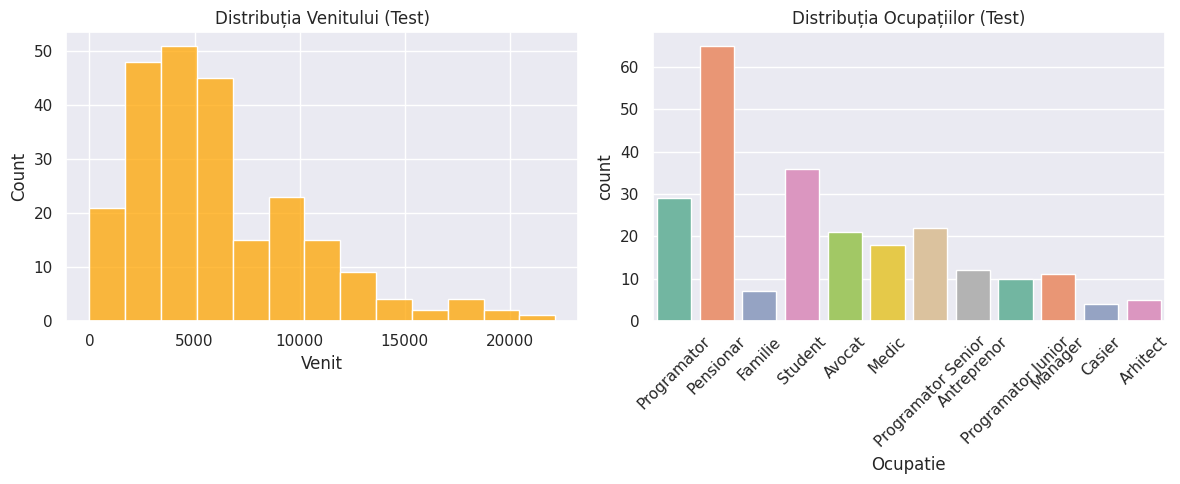

In [18]:
 print("Explorarea Datelor pentru subsetul de testarea")
valori_lipsa_test = test_df.isnull().sum()
print("Valori lipsă în setul de testare:")
print(valori_lipsa_test[valori_lipsa_test > 0])
print("\nStatistici descriptive pentru variabilele numerice:")
display(test_df.describe())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=test_df, x='Venit', color='orange')
plt.title('Distribuția Venitului (Test)')
plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x='Ocupatie', hue='Ocupatie', palette='Set2', legend=False)
plt.title('Distribuția Ocupațiilor (Test)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

În blocul acesta de cod mă asigur că acopăr și eventualele goluri din datele de testare, folosind mediana calculată mai devreme. Apoi, aplic o functie care transformă instant toate meseriile și stările civile în coduri numerice simple, gen 0, 1 sau 2.

In [19]:
test_df = pd.read_csv("test.csv")
test_df['Ore ecran zilnic'] = test_df['Ore ecran zilnic'].fillna(train_df['Ore ecran zilnic'].median())
train_df['Ocupatie'] = train_df['Ocupatie'].astype('category').cat.codes
train_df['Stare civila'] = train_df['Stare civila'].astype('category').cat.codes
test_df['Ocupatie'] = test_df['Ocupatie'].astype('category').cat.codes
test_df['Stare civila'] = test_df['Stare civila'].astype('category').cat.codes

X_train = train_df.drop('Categorie varsta', axis=1)
y_train = train_df['Categorie varsta']
X_test = test_df.drop('Categorie varsta', axis=1)
y_test = test_df['Categorie varsta']
display(X_train.head(3))

,Ocupatie,Venit,Stare civila,Economii,Ore ecran zilnic,Nivel stres,Timp liber
0,11,2928.31,2,1043.24,8.0,5.09,4
1,6,1836.11,1,133522.48,7.0,8.89,0
2,7,5425.88,0,1970.03,3.0,2.64,67


Folosim un model de tip Random Forest pentru a învăța tiparele din datele noastre. Mai întâi îl antrenăm să înțeleagă legătura dintre stilul de viață și vârstă, apoi îl testam.

La final, tragem linie și afișăm notele lui: acuratețea, raportul de performanță și matricea de confuzie.

Acuratețea modelului: 99.17%



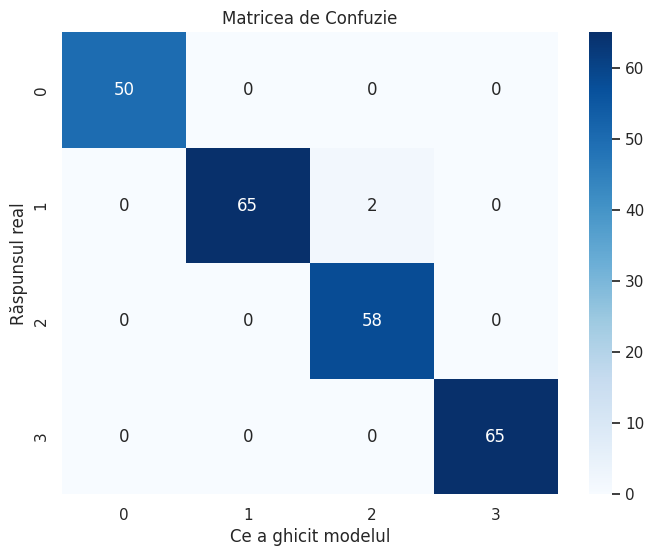

Raport de Performanță
              precision    recall  f1-score   support

       18-25       1.00      1.00      1.00        50
       26-39       1.00      0.97      0.98        67
       40-59       0.97      1.00      0.98        58
         60+       1.00      1.00      1.00        65

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



In [20]:
model = RandomForestClassifier(random_state=17)
model.fit(X_train, y_train)
predictii = model.predict(X_test)
acuratete = accuracy_score(y_test, predictii)
print(f"Acuratețea modelului: {acuratete * 100:.2f}%\n")
matrice = confusion_matrix(y_test, predictii)
plt.figure(figsize=(8, 6))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues')
plt.title('Matricea de Confuzie')
plt.xlabel('Ce a ghicit modelul')
plt.ylabel('Răspunsul real')
plt.show()
print("Raport de Performanță")
print(classification_report(y_test, predictii))